In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [86]:
y = [1, 0, 1]
y_pred = [0.9, 0.2, 0.4]

sum = 0
for i in range(3):
    sum += (y[i]*np.log(y_pred[i]) + (1 - y[i])*np.log(1 - y_pred[i]))
    print(sum)

print(1/3*sum)

-0.10536051565782628
-0.328504066972036
-1.244794798846191
-0.41493159961539694


# Logistic Regression

In [87]:
class LogisticRegression:
    def __init__ (self, lr=0.01, num_iter=1000):
        self.lr = lr
        self.num_iter = num_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
       return 1 / (1 + np.exp(-z))

    def binary_cross_entropy(self, y_true, y_pred):
        epsilon = 1e-9 
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred)
        return -np.mean(loss)

    def grad(self, X, y_true, y_pred):
        n_samples = X.shape[0]
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_true))
        db = (1 / n_samples) * np.sum(y_pred - y_true)
        return dw, db


    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return y_pred

    def predict(self, X, threshold=0.5):
        y_pred = self.predict_proba(X)
        y_pred[y_pred >= threshold] = 1.0
        y_pred[y_pred < threshold] = 0.0
        return y_pred

    def batch_generator(self, X, y, batch_size=32):
        m = X.shape[0]
        idx = np.arange(m)
        np.random.shuffle(idx)
        n_batch = m // batch_size + 1

        for i in range(n_batch):
            i_start = batch_size * i
            i_stop = min((i + 1)* batch_size, m)

            if i_start < i_stop:
                batch_idx = idx[i_start: i_stop]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                yield X_batch, y_batch

            else:
                pass

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        
        for _ in range(self.num_iter):

            for X_batch, y_batch in self.batch_generator(X, y):
                z = np.dot(X_batch, self.weights) + self.bias
                y_pred = self.sigmoid(z)
                
                dw, db = self.grad(X_batch, y_batch, y_pred)

                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            if _ % 100 == 0:
                full_pred = self.predict_proba(X)
                print(f"Epoch {_} - Loss: {self.binary_cross_entropy(y, full_pred):.4f}")

        return self.weights, self.bias

In [88]:
def evaluate_model(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1_score:.2f}")


# Diabetes

In [89]:
data_diabetes = pd.read_csv('diabetes.csv')
data_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [90]:
X = data_diabetes[data_diabetes.columns[:-1]].values
y = data_diabetes[data_diabetes.columns[-1]].values

print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

In [92]:
model = LogisticRegression(lr=0.01, num_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test, threshold=0.34)
evaluate_model(y_test, y_pred)

Epoch 0 - Loss: 0.6701
Epoch 100 - Loss: 0.4649
Epoch 200 - Loss: 0.4625
Epoch 300 - Loss: 0.4625
Epoch 400 - Loss: 0.4625
Epoch 500 - Loss: 0.4624
Epoch 600 - Loss: 0.4624
Epoch 700 - Loss: 0.4624
Epoch 800 - Loss: 0.4624
Epoch 900 - Loss: 0.4624
Accuracy: 74.03%
Precision: 0.68
Recall: 0.68
F1 Score: 0.68


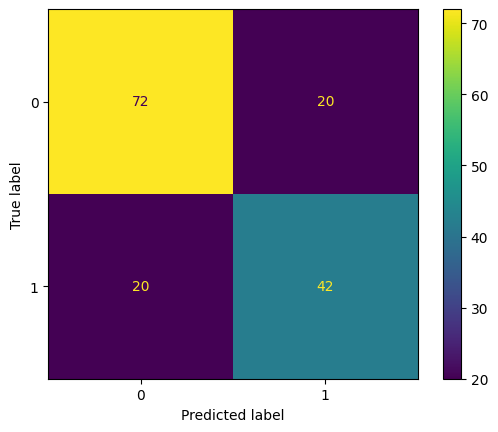

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

# Wine Quality

In [94]:
data = pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [95]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [96]:
X = data[data.columns[:-1]].values
y = data[data.columns[-1]].values

y = np.where(y > 5, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [97]:
model = LogisticRegression(lr=0.01, num_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test, threshold=0.53)
evaluate_model(y_test, y_pred)

Epoch 0 - Loss: 0.6525
Epoch 100 - Loss: 0.5125
Epoch 200 - Loss: 0.5122
Epoch 300 - Loss: 0.5122
Epoch 400 - Loss: 0.5122
Epoch 500 - Loss: 0.5122
Epoch 600 - Loss: 0.5122
Epoch 700 - Loss: 0.5122
Epoch 800 - Loss: 0.5122
Epoch 900 - Loss: 0.5122
Accuracy: 74.69%
Precision: 0.76
Recall: 0.74
F1 Score: 0.75


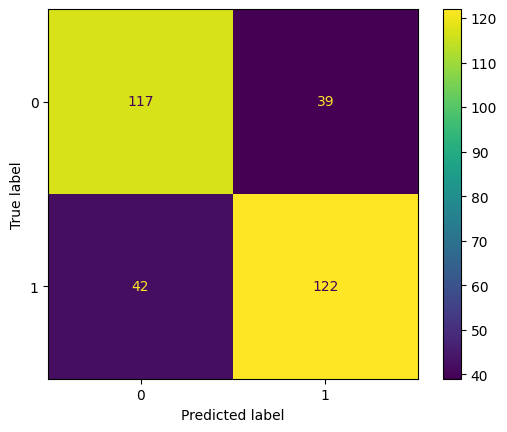

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()